In [169]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
import gif
from scipy.stats import norm
from scipy.stats import poisson


Implement the Gibbs sampler for normal distibution in the following cell.

In [170]:
def gibbs_sampler(initial_values, y, w, alfa, beta, num_posterior_samples=50):
    n = len(y)

    mu_samples = np.zeros((num_posterior_samples, 1))
    tau_samples = np.zeros((num_posterior_samples, 1))
    mu_samples[0] = initial_values[0]
    tau_samples[0] = initial_values[1]
    sum_y = np.sum(y)
    for i in range(1, num_posterior_samples):
        # 1. Sample mu | y, tau (Normal Distribution)
        # Get the previous tau sample
        current_tau = tau_samples[i-1]
        
        # Calculate Posterior Parameters for mu
        tau_post = n * current_tau + w
        mu_post = (current_tau * sum_y) / tau_post
        sigma_sq_post = 1 / tau_post # Variance
        
        # Draw new mu sample
        mu_samples[i] = np.random.normal(loc=mu_post, scale=np.sqrt(sigma_sq_post))
        
        # 2. Sample tau | y, mu (Gamma Distribution)
        # Get the current mu sample (essential for Gibbs)
        current_mu = mu_samples[i] 
        
        # Calculate Posterior Parameters for tau
        alfa_post = alfa + n / 2
        beta_post = beta + 0.5 * np.sum((y - current_mu)**2)
        
        # Draw new tau sample
        # Note: numpy.random.gamma uses 'shape' (alfa_post) and 'scale' (1/beta_post)
        tau_samples[i] = np.random.gamma(shape=alfa_post, scale=1/beta_post)
    return mu_samples, tau_samples


In [171]:
# To create a gif image
@gif.frame
def plot_samples_normal(x, true_pdf, estimated_pdf, num_samples, title="Gibbs Sampling Normal dist",):
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.gca()
    
    # Plot the true distribution
    ax.plot(x, true_pdf, label = "True distribution")
    
    # Plot the estimated distribution after each iteration
    ax.plot(x, estimated_pdf, label = "Estimated distribution after "+str(num_samples)+" iterations")
    
    # Keeping the axes scales same for good gifs
    # ax.set_xlim(xlims)
    ax.set_ylim((0, 0.3))
    
    
    ax.legend(loc='upper left')
    ax.set_title(title)

In [172]:
#Simulate data to check the Gibbs sampler
n = 100 #sample size
sigma_true = 2
sigma2_true = sigma_true**2
mu_true = 5
np.random.seed(4)
y = mu_true + np.random.randn(n)*sigma_true

In [173]:
initial_values = [1,5]
alpha = 1
beta = 1
w = 1
num_posterior_samples = 50

mu_samples,tau_samples = gibbs_sampler(initial_values, y, w, alpha, beta, num_posterior_samples)

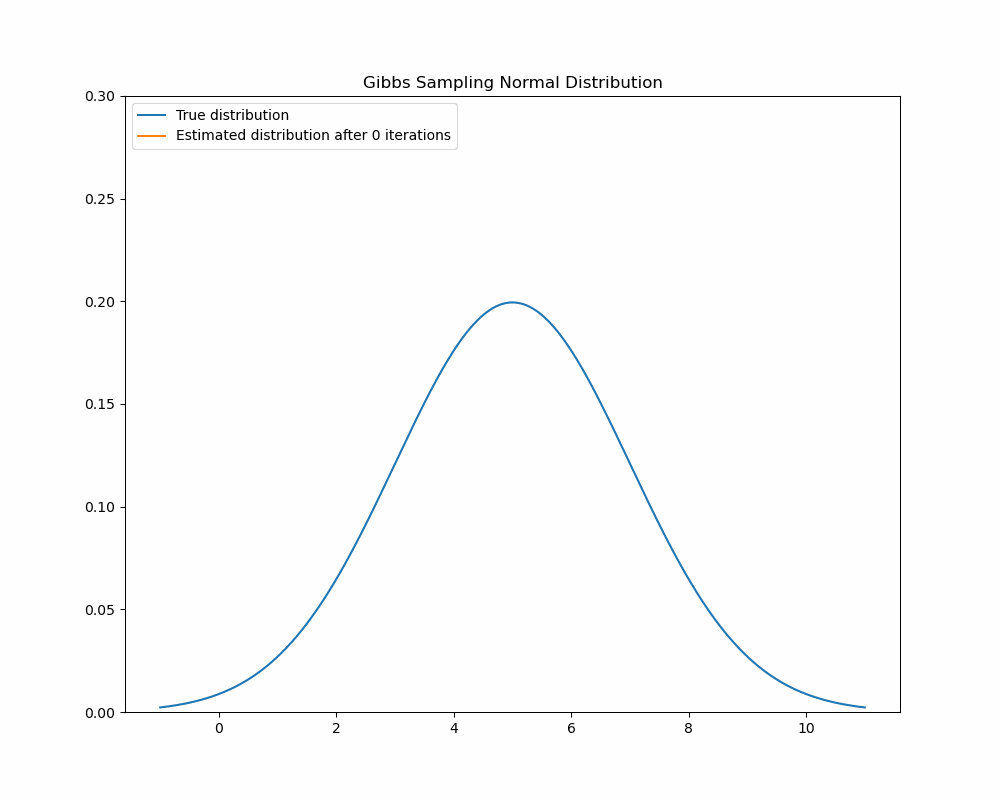

In [174]:
# Creating the gif
x = np.linspace(mu_true-3*sigma_true, mu_true + 3*sigma_true, 1000 )
true_pdf = norm.pdf(x, mu_true, sigma_true)

frames = []
for num_samples in range(len(mu_samples)):
    mu = np.mean(mu_samples[:num_samples])
    sigma = 1/np.sqrt(np.mean(tau_samples[:num_samples]))
    estimated_pdf = norm.pdf(x, mu, sigma)
    

    frame = plot_samples_normal(x, true_pdf, estimated_pdf, num_samples,title="Gibbs Sampling Normal Distribution")
    frames.append(frame)

gif.save(frames, "gibbs_normal.gif", duration=150)
Image(filename="gibbs_normal.gif")

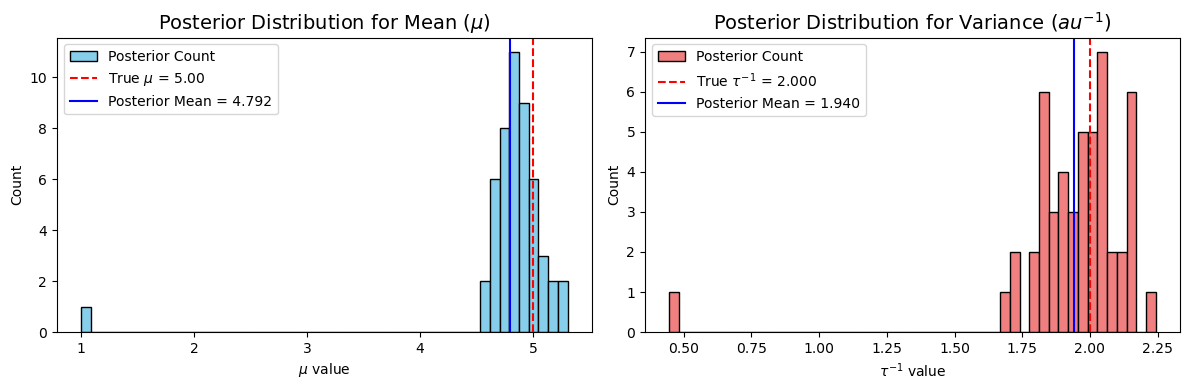

In [175]:
var_samples = 1 / np.sqrt(tau_samples)

# Calculate Posterior Means
mu_posterior_mean = np.mean(mu_samples)
var_posterior_mean = np.mean(var_samples)

# --- Plotting Code (Modified for Counts) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mu Histogram
axes[0].hist(
    mu_samples,
    bins=50,
    # Removed: density=True to show absolute counts
    color='skyblue',
    edgecolor='black',
    label='Posterior Count' # Updated label
)
axes[0].axvline(x=mu_true, color='r', linestyle='--', label=f'True $\mu$ = {mu_true:.2f}')
axes[0].axvline(x=mu_posterior_mean, color='b', linestyle='-', label=f'Posterior Mean = {mu_posterior_mean:.3f}')
axes[0].set_title('Posterior Distribution for Mean ($\mu$)', fontsize=14)
axes[0].set_xlabel('$\mu$ value')
axes[0].set_ylabel('Count') # Updated label
axes[0].legend()

# Variance (tau^-1) Histogram
axes[1].hist(
    var_samples,
    bins=50,
    # Removed: density=True to show absolute counts
    color='lightcoral',
    edgecolor='black',
    label='Posterior Count' # Updated label
)
axes[1].axvline(x=sigma_true, color='r', linestyle='--', label=f'True $\\tau^{{-1}}$ = {sigma_true:.3f}')
axes[1].axvline(x=var_posterior_mean, color='b', linestyle='-', label=f'Posterior Mean = {var_posterior_mean:.3f}')
axes[1].set_title('Posterior Distribution for Variance ($\tau^{-1}$)', fontsize=14)
axes[1].set_xlabel('$\\tau^{-1}$ value')
axes[1].set_ylabel('Count') # Updated label
axes[1].legend()

plt.tight_layout()
plt.show()

Implement the Gibbs sampler for poisson distibution in the following cell.

In [176]:
# Gibbs sampler
def gibbs_sampler_pois(initial_values, y, num_posterior_samples):
    n = len(y)
    mu_samples = np.zeros((num_posterior_samples, 1))
    beta_samples = np.zeros((num_posterior_samples, 1))
    mu_samples[0] = initial_values[0]
    beta_samples[0] = initial_values[1]

    sum_y = np.sum(y)

    # Gibbs Sampling Loop
    for i in range(1, num_posterior_samples):
        # 1. Sample mu | y, beta (Gamma Distribution)
        
        # Get the previous beta sample
        current_beta = beta_samples[i-1] 
        
        # Calculate Posterior Parameters for mu
        # Shape: alpha_post = 2 + sum(y_i)
        # Rate: beta_post = n + current_beta
        alfa_mu_post = 2 + sum_y
        beta_mu_post = n + current_beta
        
        mu_samples[i] = np.random.gamma(shape=alfa_mu_post, scale=1/beta_mu_post)
        
     
        current_mu = mu_samples[i] 
        
        # Calculate Posterior Parameters for beta
        # Shape: alpha_post = 3
        # Rate: beta_post = 1 + current_mu
        alfa_beta_post = 3
        beta_beta_post = 1 + current_mu
        
        # Draw new beta sample
        beta_samples[i] = np.random.gamma(shape=alfa_beta_post, scale=1/beta_beta_post)

    return mu_samples, beta_samples

In [177]:
# Generate y values
n = 100 #sample size
true_param = 5
np.random.seed(4)
y_pois = np.random.poisson(true_param, n)

In [178]:
initial_values = [1,2]
num_posterior_samples = 50

mu_samples, beta_samples = gibbs_sampler_pois(initial_values, y_pois, num_posterior_samples)

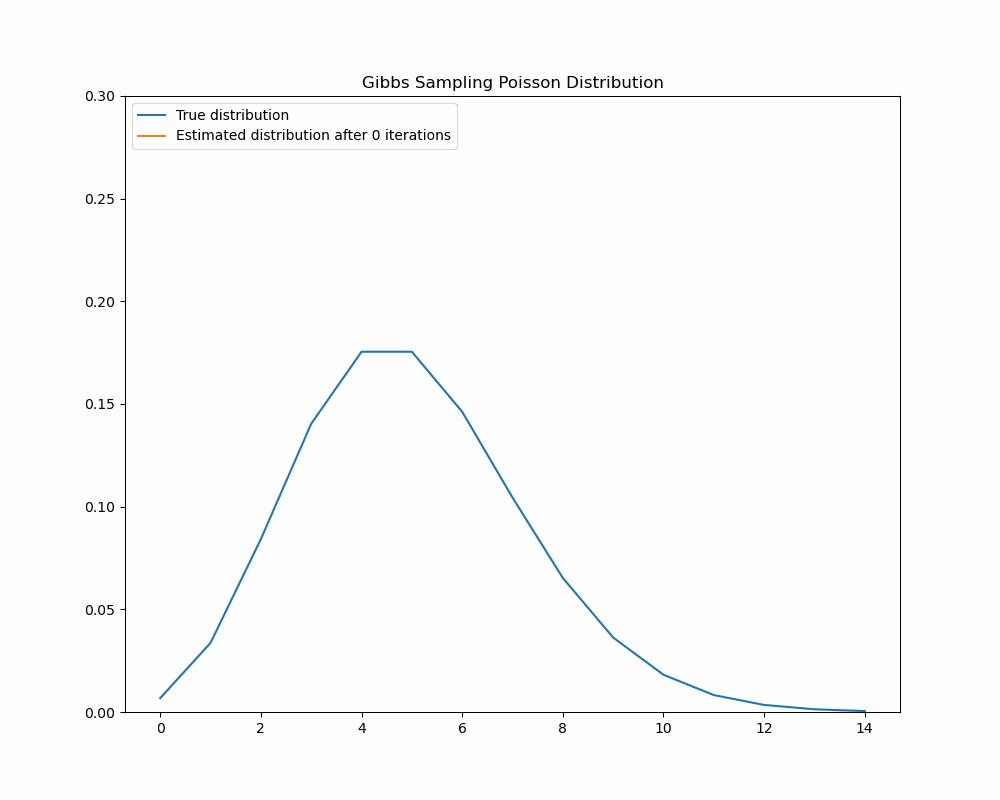

In [179]:
# Creating the gif
x = np.arange(0,15)
true_pdf = poisson.pmf(x, true_param)

frames = []
for num_samples in range(len(mu_samples)):
    mu = np.mean(mu_samples[:num_samples])
    estimated_pdf = poisson.pmf(x, mu)
    
    frame = plot_samples_normal(x, true_pdf, estimated_pdf, num_samples, title="Gibbs Sampling Poisson Distribution")
    frames.append(frame)

gif.save(frames, "gibbs_poisson.gif", duration=150)
Image(filename="gibbs_poisson.gif")

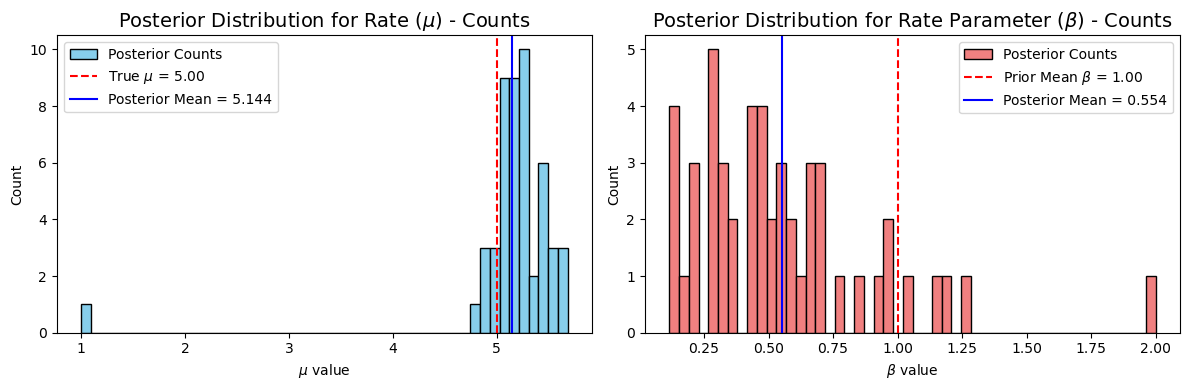

In [ ]:
mu_posterior_mean = np.mean(mu_samples)
beta_posterior_mean = np.mean(beta_samples)
mu_true = 5.0      # True value for mu (from Poisson(5) simulation)
BETA_TRUE = 1.0    # Theoretical expected value for beta

# --- Plotting Code (Switched density=True to density=False) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Mu Histogramß
axes[0].hist(mu_samples, bins=50, density=False, color='skyblue', edgecolor='black', label='Posterior Counts')
axes[0].axvline(x=mu_true, color='r', linestyle='--', label=f'True $\mu$ = {mu_true:.2f}')
axes[0].axvline(x=mu_posterior_mean, color='b', linestyle='-', label=f'Posterior Mean = {mu_posterior_mean:.3f}')
axes[0].set_title('Posterior Distribution for Rate ($\mu$) - Counts', fontsize=14)
axes[0].set_xlabel('$\mu$ value')
axes[0].set_ylabel('Count') # Label updated
axes[0].legend()

# 2. Beta Histogram
axes[1].hist(beta_samples, bins=50, density=False, color='lightcoral', edgecolor='black', label='Posterior Counts')
axes[1].axvline(x=BETA_TRUE, color='r', linestyle='--', label=f'Prior Mean $\\beta$ = {BETA_TRUE:.2f}') 
axes[1].axvline(x=beta_posterior_mean, color='b', linestyle='-', label=f'Posterior Mean = {beta_posterior_mean:.3f}')
axes[1].set_title('Posterior Distribution for Rate Parameter ($\\beta$) - Counts', fontsize=14)
axes[1].set_xlabel('$\\beta$ value') 
axes[1].set_ylabel('Count') # Label updated
axes[1].legend()

plt.tight_layout()
plt.savefig('posterior_distributions.svg')
plt.show()